Parameter               | Value    | Unit    | Comment                                  
------------------------+----------+---------+------------------------------------------
spot_diameter_cm        | 0.5      | cm      | Probe window diameter                    
spot_offset_cm          | 2        | cm      | Probe centre radius from wheel origin    
depth_cm                | 0.1      | cm      | Sampling depth into powder               
density_g_per_cm3       | 0.3      | g/cm3   | Bulk powder density                      
finger_width_cm         | 0.3      | cm      | Finger tangential width                  
finger_length_cm        | 3        | cm      | Finger radial length (wheel radius)      
num_fingers             | 4        | -       | Number of fingers                        
rpm                     | 20       | rev/min | Wheel speed                              
acquisition_time_s      | 1        | s       | NIR integration time                     
—                    

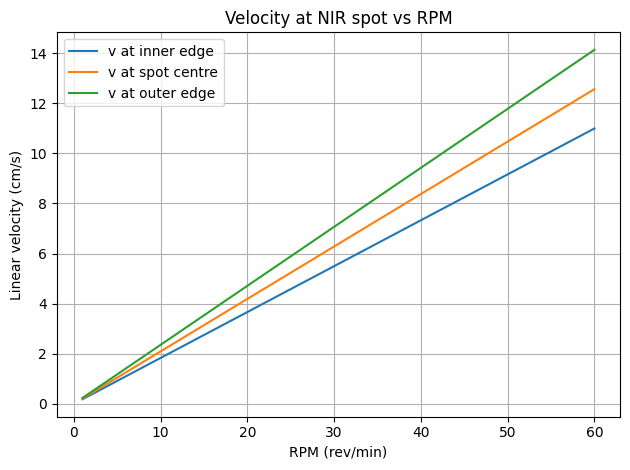

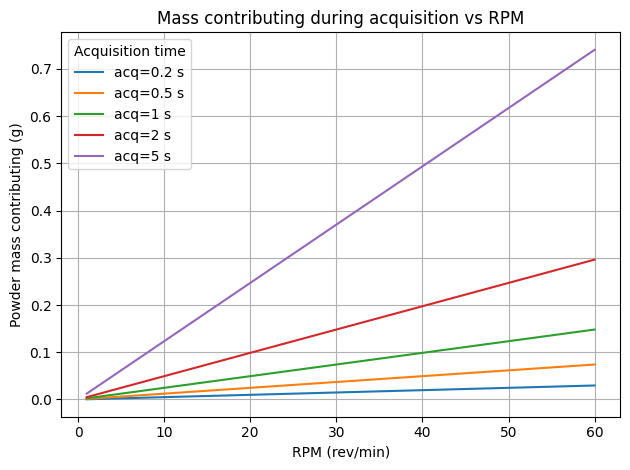


Plots saved:
 - velocity_at_spot_vs_rpm.png
 - mass_contributing_vs_rpm_multi_acq.png


In [25]:
"""
Spiderwheel NIR interface simulation (expanded)

Adds:
1) Plot: velocity at the NIR spot (inner/centre/outer) vs RPM over a user-defined RPM range.
2) Plot: powder mass contributing vs RPM, with one line per acquisition time (array).
3) Console output as a table that includes BOTH inputs and results.

Notes:
- RPM is revolutions per minute (rotations per minute).
- Tangential velocity uses v = ω r, where ω = 2π * RPM / 60.
- Detection volume is treated as a short cylinder: V = π r_spot^2 * depth.
- "Mass contributing during acquisition" is estimated as detection_mass * refreshes,
  where refreshes = acquisition_time / (spot_diameter / v_center). This is a mixing/refresh proxy.

Run examples:
    python spiderwheel_simulation.py --rpm 10
    python spiderwheel_simulation.py --plot-rpm-range --rpm-min 1 --rpm-max 60 --rpm-step 1
    python spiderwheel_simulation.py --plot-mass-grid --rpms 1,2,5,10,20,30,40,50 --acq-times 0.2,0.5,1,2,5
"""

from __future__ import annotations

import argparse
import math
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np

try:
    import matplotlib.pyplot as plt  # Optional, only needed for plotting
except ImportError:
    plt = None



# -----------------------------
# Data structures
# -----------------------------
@dataclass
class Inputs:
    spot_diameter_cm: float = 0.5
    spot_offset_cm: float = 2.0
    depth_cm: float = 0.1
    density_g_per_cm3: float = 0.3
    finger_width_cm: float = 0.3
    finger_length_cm: float = 3.0
    num_fingers: int = 4
    rpm: float = 10.0
    acquisition_time_s: float = 1.0


@dataclass
class Outputs:
    detection_volume_cm3: float
    detection_mass_g: float
    v_inner_cm_per_s: float
    v_center_cm_per_s: float
    v_outer_cm_per_s: float
    coverage_fraction: float
    coverage_time_s: float
    volume_contributing_cm3: float
    mass_contributing_g: float


# -----------------------------
# Core physics/helpers
# -----------------------------
def rpm_to_omega_rad_s(rpm: float) -> float:
    """Convert revolutions per minute (RPM) to angular speed ω in rad/s."""
    return 2.0 * math.pi * rpm / 60.0


def detection_volume_cm3(spot_diameter_cm: float, depth_cm: float) -> float:
    """Cylindrical approximation of NIR sampling volume: V = π r^2 h."""
    r = spot_diameter_cm / 2.0
    return math.pi * r * r * depth_cm


def format_table(rows: List[List[str]], headers: List[str]) -> str:
    """
    Minimal, dependency-free table formatter (fixed-width).
    Good for console logs and avoids external packages.
    """
    # Determine column widths
    cols = list(zip(*([headers] + rows)))
    widths = [max(len(str(x)) for x in col) for col in cols]

    def fmt_row(row: List[str]) -> str:
        return " | ".join(str(cell).ljust(w) for cell, w in zip(row, widths))

    sep = "-+-".join("-" * w for w in widths)
    out = [fmt_row(headers), sep]
    out += [fmt_row(r) for r in rows]
    return "\n".join(out)


# -----------------------------
# Simulation
# -----------------------------
def simulate(inp: Inputs) -> Outputs:
    """
    Run a single simulation scenario.
    """
    # Geometry
    r_spot = inp.spot_diameter_cm / 2.0
    v_det_cm3 = detection_volume_cm3(inp.spot_diameter_cm, inp.depth_cm)
    m_det_g = v_det_cm3 * inp.density_g_per_cm3

    # Kinematics
    omega = rpm_to_omega_rad_s(inp.rpm)  # rad/s

    r_inner = max(inp.spot_offset_cm - r_spot, 0.0)
    r_outer = inp.spot_offset_cm + r_spot

    v_inner = omega * r_inner
    v_center = omega * inp.spot_offset_cm
    v_outer = omega * r_outer

    # Finger coverage (simple geometric duty cycle at probe radius)
    circumference = 2.0 * math.pi * inp.spot_offset_cm
    total_covered_length = inp.num_fingers * inp.finger_width_cm
    coverage_fraction = (total_covered_length / circumference) if circumference > 0 else 0.0
    coverage_fraction = max(0.0, min(coverage_fraction, 1.0))
    coverage_time = inp.acquisition_time_s * coverage_fraction

    # Powder "refresh" across probe window during acquisition
    # time_to_cross_spot ≈ spot_diameter / v_center (if v_center > 0)
    if v_center > 0:
        time_to_cross_spot = (2.0 * r_spot) / v_center
        refreshes = inp.acquisition_time_s / time_to_cross_spot
        v_contrib_cm3 = v_det_cm3 * refreshes
    else:
        v_contrib_cm3 = 0.0

    m_contrib_g = v_contrib_cm3 * inp.density_g_per_cm3

    return Outputs(
        detection_volume_cm3=v_det_cm3,
        detection_mass_g=m_det_g,
        v_inner_cm_per_s=v_inner,
        v_center_cm_per_s=v_center,
        v_outer_cm_per_s=v_outer,
        coverage_fraction=coverage_fraction,
        coverage_time_s=coverage_time,
        volume_contributing_cm3=v_contrib_cm3,
        mass_contributing_g=m_contrib_g,
    )


# -----------------------------
# Printing
# -----------------------------
def print_simulation_table(inp: Inputs, out: Outputs) -> None:
    """
    Print a single-run result in a compact table including inputs and outputs.
    """
    rows = [
        ["spot_diameter_cm", f"{inp.spot_diameter_cm:g}", "cm", "Probe window diameter"],
        ["spot_offset_cm", f"{inp.spot_offset_cm:g}", "cm", "Probe centre radius from wheel origin"],
        ["depth_cm", f"{inp.depth_cm:g}", "cm", "Sampling depth into powder"],
        ["density_g_per_cm3", f"{inp.density_g_per_cm3:g}", "g/cm3", "Bulk powder density"],
        ["finger_width_cm", f"{inp.finger_width_cm:g}", "cm", "Finger tangential width"],
        ["finger_length_cm", f"{inp.finger_length_cm:g}", "cm", "Finger radial length (wheel radius)"],
        ["num_fingers", f"{inp.num_fingers:d}", "-", "Number of fingers"],
        ["rpm", f"{inp.rpm:g}", "rev/min", "Wheel speed"],
        ["acquisition_time_s", f"{inp.acquisition_time_s:g}", "s", "NIR integration time"],
        ["—", "—", "—", "—"],
        ["detection_volume_cm3", f"{out.detection_volume_cm3:.6f}", "cm3", "Static detection volume"],
        ["detection_mass_g", f"{out.detection_mass_g:.6f}", "g", "Static detection mass"],
        ["v_inner_cm_per_s", f"{out.v_inner_cm_per_s:.6f}", "cm/s", "Velocity at inner edge of spot"],
        ["v_center_cm_per_s", f"{out.v_center_cm_per_s:.6f}", "cm/s", "Velocity at spot centre"],
        ["v_outer_cm_per_s", f"{out.v_outer_cm_per_s:.6f}", "cm/s", "Velocity at outer edge of spot"],
        ["coverage_fraction", f"{out.coverage_fraction:.4f}", "-", "Fraction of time spot is blocked"],
        ["coverage_time_s", f"{out.coverage_time_s:.6f}", "s", "Blocked time during acquisition"],
        ["volume_contributing_cm3", f"{out.volume_contributing_cm3:.6f}", "cm3", "Estimated volume sampled over acquisition"],
        ["mass_contributing_g", f"{out.mass_contributing_g:.6f}", "g", "Estimated mass sampled over acquisition"],
    ]
    headers = ["Parameter", "Value", "Unit", "Comment"]
    print(format_table(rows, headers))


# -----------------------------
# Plotting
# -----------------------------
def plot_velocity_at_spot_vs_rpm(
    base_inputs: Inputs,
    rpms: np.ndarray,
    savepath: str | None = None,
    show: bool = True,
) -> None:
    """
    Plot v(r) at the NIR spot (inner/centre/outer) as a function of RPM.
    """
    if plt is None:
        raise RuntimeError("matplotlib is not available. Install matplotlib to use plotting.")

    r_spot = base_inputs.spot_diameter_cm / 2.0
    r_inner = max(base_inputs.spot_offset_cm - r_spot, 0.0)
    r_center = base_inputs.spot_offset_cm
    r_outer = base_inputs.spot_offset_cm + r_spot

    omega = rpm_to_omega_rad_s(rpms)  # vectorized
    v_inner = omega * r_inner
    v_center = omega * r_center
    v_outer = omega * r_outer

    plt.figure()
    plt.plot(rpms, v_inner, label="v at inner edge")
    plt.plot(rpms, v_center, label="v at spot centre")
    plt.plot(rpms, v_outer, label="v at outer edge")
    plt.xlabel("RPM (rev/min)")
    plt.ylabel("Linear velocity (cm/s)")
    plt.title("Velocity at NIR spot vs RPM")
    plt.grid(True)
    plt.legend()

    if savepath:
        plt.tight_layout()
        plt.savefig(savepath, dpi=150)
    if show:
        plt.show()
    else:
        plt.close()


def plot_mass_contributing_grid(
    base_inputs: Inputs,
    rpms: np.ndarray,
    acquisition_times_s: np.ndarray,
    savepath: str | None = None,
    show: bool = True,
) -> None:
    """
    Plot mass contributing vs RPM, with one line per acquisition time.

    Each line corresponds to base_inputs with acquisition_time_s replaced by that value.
    """
    if plt is None:
        raise RuntimeError("matplotlib is not available. Install matplotlib to use plotting.")

    masses = []
    for t in acquisition_times_s:
        inp = Inputs(**vars(base_inputs))
        inp.acquisition_time_s = float(t)
        y = []
        for rpm in rpms:
            inp.rpm = float(rpm)
            out = simulate(inp)
            y.append(out.mass_contributing_g)
        masses.append(np.array(y))

    plt.figure()
    for t, y in zip(acquisition_times_s, masses):
        plt.plot(rpms, y, label=f"acq={t:g} s")

    plt.xlabel("RPM (rev/min)")
    plt.ylabel("Powder mass contributing (g)")
    plt.title("Mass contributing during acquisition vs RPM")
    plt.grid(True)
    plt.legend(title="Acquisition time")

    if savepath:
        plt.tight_layout()
        plt.savefig(savepath, dpi=150)
    if show:
        plt.show()
    else:
        plt.close()


# Vectorized helper for omega (supports numpy arrays)
def rpm_to_omega_rad_s(rpm):  # type: ignore[override]
    return 2.0 * np.pi * np.asarray(rpm, dtype=float) / 60.0


def parse_csv_floats(s: str) -> np.ndarray:
    return np.array([float(x.strip()) for x in s.split(",") if x.strip() != ""], dtype=float)


# -----------------------------
# CLI
# -----------------------------
def build_arg_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(
        description="Simulate spiderwheel powder interface for NIR probe (with plots)."
    )

    # Base parameters
    p.add_argument("--spot-diameter", type=float, default=0.5, help="Probe window diameter (cm)")
    p.add_argument("--spot-offset", type=float, default=2.0, help="Probe centre radius (cm)")
    p.add_argument("--depth", type=float, default=0.1, help="Sampling depth (cm)")
    p.add_argument("--density", type=float, default=0.3, help="Powder density (g/cm^3)")
    p.add_argument("--finger-width", type=float, default=0.3, help="Finger tangential width (cm)")
    p.add_argument("--finger-length", type=float, default=3.0, help="Finger radial length (cm)")
    p.add_argument("--num-fingers", type=int, default=4, help="Number of fingers")
    p.add_argument("--rpm", type=float, default=10.0, help="Single-run RPM (rev/min)")
    p.add_argument("--acq-time", type=float, default=1.0, help="Single-run acquisition time (s)")

    # Plots
    p.add_argument("--plot-rpm-range", action="store_true", help="Plot velocity-at-spot vs RPM over a range")
    p.add_argument("--rpm-min", type=float, default=1.0, help="Min RPM for RPM-range plots")
    p.add_argument("--rpm-max", type=float, default=60.0, help="Max RPM for RPM-range plots")
    p.add_argument("--rpm-step", type=float, default=1.0, help="Step RPM for RPM-range plots")

    p.add_argument("--plot-mass-grid", action="store_true", help="Plot mass contributing vs RPM for multiple acquisition times")
    p.add_argument("--rpms", type=str, default="", help="CSV list of RPMs for mass-grid plot, e.g. '1,2,5,10,20'")
    p.add_argument("--acq-times", type=str, default="0.2,0.5,1,2,5", help="CSV list of acquisition times (s)")

    p.add_argument("--save-plots", action="store_true", help="Save plots to PNG files")
    return p


def main(argv: List[str] | None = None) -> None:
    parser = build_arg_parser()

    # IMPORTANT for Jupyter: use parse_known_args so ipykernel's extra args (e.g. -f ...) don't crash.
    args, _unknown = parser.parse_known_args(argv)

    base = Inputs(
        spot_diameter_cm=args.spot_diameter,
        spot_offset_cm=args.spot_offset,
        depth_cm=args.depth,
        density_g_per_cm3=args.density,
        finger_width_cm=args.finger_width,
        finger_length_cm=args.finger_length,
        num_fingers=args.num_fingers,
        rpm=args.rpm,
        acquisition_time_s=args.acq_time,
    )

    # Single-run simulation + table print
    out = simulate(base)
    print_simulation_table(base, out)

    if plt is None and (args.plot_rpm_range or args.plot_mass_grid):
        print("\nmatplotlib is not available; skipping plots.")
        return

    # Plot 1: velocity at NIR spot vs RPM
    if args.plot_rpm_range:
        rpms = np.arange(args.rpm_min, args.rpm_max + 1e-12, args.rpm_step, dtype=float)
        savepath = "velocity_at_spot_vs_rpm.png" if args.save_plots else None
        plot_velocity_at_spot_vs_rpm(base, rpms, savepath=savepath, show=True)

    # Plot 2: mass contributing vs RPM for multiple acquisition times
    if args.plot_mass_grid:
        if args.rpms.strip():
            rpms = parse_csv_floats(args.rpms)
        else:
            rpms = np.arange(args.rpm_min, args.rpm_max + 1e-12, args.rpm_step, dtype=float)

        acq_times = parse_csv_floats(args.acq_times)
        savepath = "mass_contributing_vs_rpm_multi_acq.png" if args.save_plots else None
        plot_mass_contributing_grid(base, rpms, acq_times, savepath=savepath, show=True)


# ============================
# JUPYTER AUTO-RUN SECTION
# ============================

# This block makes the script run automatically in a notebook cell
# and generates + saves plots without CLI arguments.

import numpy as np

# Ensure plots show inline in notebooks
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# ---- Base configuration (EDIT THESE) ----
base = Inputs(
    spot_diameter_cm=0.5,
    spot_offset_cm=1.8,
    depth_cm=0.1,
    density_g_per_cm3=0.3,
    finger_width_cm=0.3,
    finger_length_cm=3.0,
    num_fingers=4,
    rpm=20.0,
    acquisition_time_s=1.0,
)

# ---- Print single-run results ----
out = simulate(base)
print_simulation_table(base, out)

# ---- RPM range for plots ----
rpms = np.arange(1, 61, 1)  # 1–60 RPM

# ---- Acquisition times for mass plot ----
acq_times = np.array([0.2, 0.5, 1.0, 2.0, 5.0])

# ---- Plot 1: Velocity at NIR spot vs RPM ----
plot_velocity_at_spot_vs_rpm(
    base_inputs=base,
    rpms=rpms,
    savepath="velocity_at_spot_vs_rpm.png",
    show=True,
)

# ---- Plot 2: Mass contributing vs RPM ----
plot_mass_contributing_grid(
    base_inputs=base,
    rpms=rpms,
    acquisition_times_s=acq_times,
    savepath="mass_contributing_vs_rpm_multi_acq.png",
    show=True,
)

print("\nPlots saved:")
print(" - velocity_at_spot_vs_rpm.png")
print(" - mass_contributing_vs_rpm_multi_acq.png")



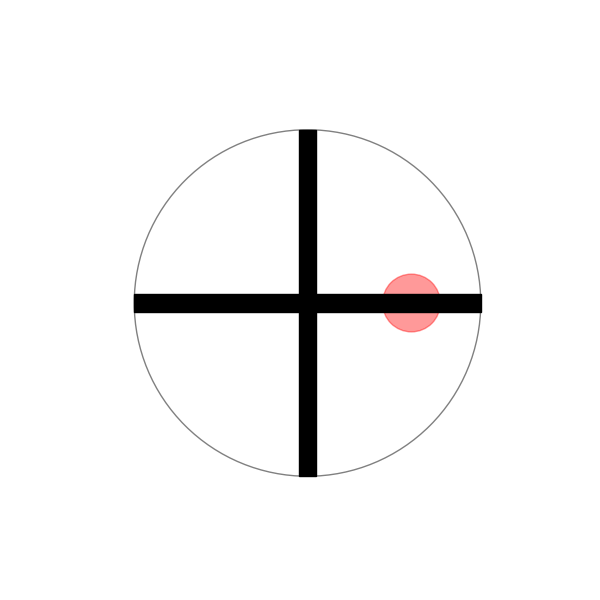

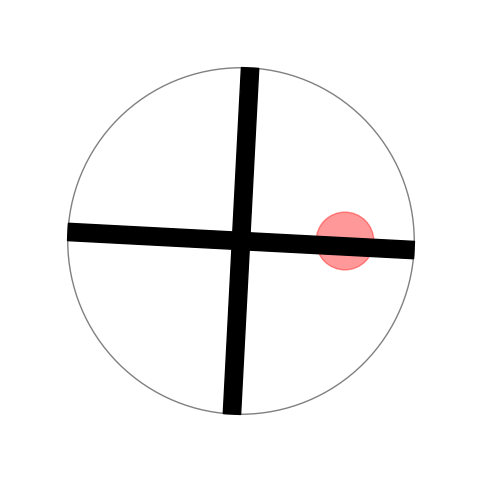

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle
from matplotlib.animation import FuncAnimation, PillowWriter
# --------------------------------------------------------------
# Simulation parameters (edit these as needed)
spot_diameter = 1      # cm (diameter of the NIR probe window)
spot_offset = 1.8        # cm (distance from wheel centre to probe centre)
finger_width = 0.3       # cm (tangential width of each finger)
finger_length = 3.0      # cm (radial length of each finger, i.e. wheel "radius")
num_fingers = 4          # number of fingers on the wheel
rpm = 10.0               # rotations per minute (wheel speed)
# Frames per second
fps = 20
# Calculate duration for exactly one full rotation (seamless loop)
duration = 60.0 / rpm  # time for one complete rotation in seconds
# --------------------------------------------------------------
# Derived parameter: angular speed (rad/s)
omega = 2.0 * np.pi * rpm / 60.0
# Create figure and axes
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
limit = finger_length + 1.0
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.axis('off')
# Draw wheel boundary (for reference)
wheel_boundary = Circle((0.0, 0.0), finger_length, fill=False,
                        edgecolor='gray', linewidth=1.0)
ax.add_patch(wheel_boundary)
# Draw NIR probe window (spot) in red (semi-transparent)
nir_spot = Circle((spot_offset, 0.0), spot_diameter / 2.0,
                  color='red', alpha=0.4)
ax.add_patch(nir_spot)
# Prepare finger patches and store their base geometry
finger_patches = []
for k in range(num_fingers):
    base_angle = k * 2.0 * np.pi / num_fingers
    # Define a rectangle in local (radial u, tangential v) coordinates:
    # [ (u,v) = (0, -W/2), (L, -W/2), (L, W/2), (0, W/2) ]
    coords_uv = np.array([
        [0.0, -finger_width / 2.0],
        [finger_length, -finger_width / 2.0],
        [finger_length,  finger_width / 2.0],
        [0.0,  finger_width / 2.0]
    ])
    # Initial rotation matrix for the base angle
    rot0 = np.array([
        [np.cos(base_angle), -np.sin(base_angle)],
        [np.sin(base_angle),  np.cos(base_angle)]
    ])
    # Convert to x-y coordinates
    verts = coords_uv @ rot0.T
    poly = Polygon(verts, closed=True, color='black')
    ax.add_patch(poly)
    finger_patches.append((poly, coords_uv, base_angle))
# Update function for animation
def update(frame):
    t = frame / fps  # convert frame index to time (s)
    angle = omega * t
    for poly, coords_uv, base_angle in finger_patches:
        phi = base_angle + angle
        rot = np.array([
            [np.cos(phi), -np.sin(phi)],
            [np.sin(phi),  np.cos(phi)]
        ])
        new_verts = coords_uv @ rot.T
        poly.set_xy(new_verts)
    return [poly for poly, _, _ in finger_patches]
# Create animation
n_frames = int(duration * fps)
ani = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000.0 / fps,
    blit=True,
    repeat=True  # Enable looping
)
# Save animation as a GIF with looping enabled
writer = PillowWriter(fps=fps)
ani.save("wheel_animation.gif", writer=writer)
# Display the GIF inline (if run in a Jupyter notebook)
from IPython.display import Image
Image(filename="wheel_animation.gif")

Parameter                  | Value    | Unit    | Comment                                                 
---------------------------+----------+---------+---------------------------------------------------------
spot_diameter_cm           | 0.5      | cm      | Probe window diameter                                   
spot_offset_cm             | 1.8      | cm      | Probe centre radius from wheel origin                   
depth_cm                   | 0.05     | cm      | Sampling depth into powder                              
density_g_per_cm3          | 0.5      | g/cm3   | Powder bulk density                                     
finger_width_cm            | 0.3      | cm      | Finger tangential width                                 
finger_length_cm           | 3        | cm      | Finger radial length (wheel radius)                     
num_fingers                | 4        | -       | Number of fingers                                       
rpm                        | 25      

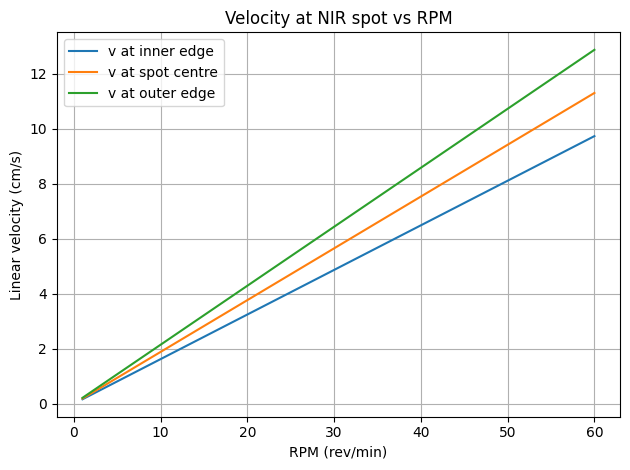

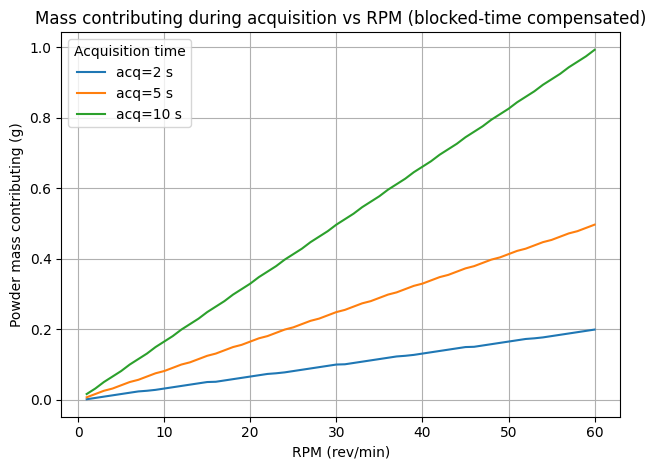

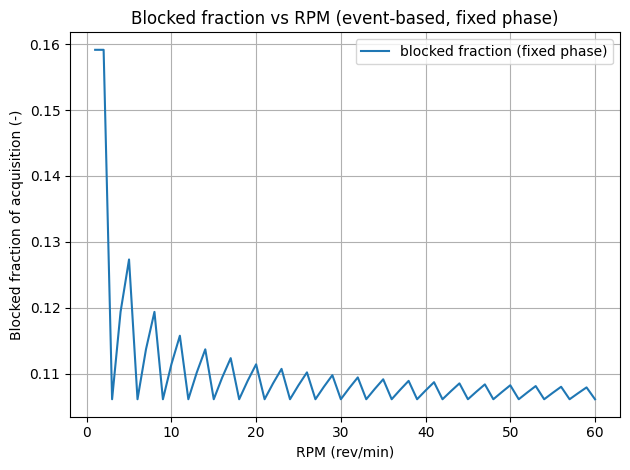


Saved plots:
 - velocity_at_spot_vs_rpm.png
 - mass_contributing_vs_rpm_multi_acq.png
 - blocked_fraction_vs_rpm.png


In [49]:
"""
Spiderwheel NIR interface simulation (fixed-phase, event-based finger blocking)
UPDATED:
- Mass contributing is now COMPENSATED for blocked time:
    effective_time = acquisition_time - coverage_time
  (i.e., when a finger blocks the probe, no material is analyzed.)
- Plots are GENERATED and SAVED automatically when you run the script (CLI or notebook cell).

What this script does
- Computes velocities at the NIR spot (inner/centre/outer) for a given RPM.
- Computes how much of a SPECIFIC acquisition window [0, T] is blocked by one or
  more wheel fingers that pass the probe during that window (event-based, fixed phase).
- Computes a simple "powder mass contributing" proxy during the UNBLOCKED part of acquisition.
- Prints results in a table including BOTH inputs and outputs.
- Generates and saves plots:
    1) velocity_at_spot_vs_rpm.png
    2) mass_contributing_vs_rpm_multi_acq.png
    3) blocked_fraction_vs_rpm.png

No animation/GIF code included.
"""

from __future__ import annotations

import argparse
import math
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np

try:
    import matplotlib.pyplot as plt  # required for plotting
except ImportError:
    plt = None


# =============================================================================
# Data structures
# =============================================================================
@dataclass
class Inputs:
    # Probe / powder
    spot_diameter_cm: float = 0.5
    spot_offset_cm: float = 1.8
    depth_cm: float = 0.05
    density_g_per_cm3: float = 0.5

    # Wheel geometry
    finger_width_cm: float = 0.3
    finger_length_cm: float = 3.0
    num_fingers: int = 4

    # Operating conditions
    rpm: float = 25.0
    acquisition_time_s: float = 10.0

    # Fixed-phase (deterministic)
    initial_phase_rad: float = 0.0  # phase of finger #0 at t=0
    probe_angle_rad: float = 0.0    # probe angular position (reference angle)


@dataclass
class Outputs:
    # Detection volume / mass
    detection_volume_cm3: float
    detection_mass_g: float

    # Velocities at NIR spot
    v_inner_cm_per_s: float
    v_center_cm_per_s: float
    v_outer_cm_per_s: float

    # Event-based blocking (fixed phase)
    t_block_per_pass_s: float
    n_pass_events_in_window: int
    coverage_time_s: float
    coverage_fraction: float

    # Powder refresh proxy (BLOCK-COMPENSATED)
    effective_unblocked_time_s: float
    volume_contributing_cm3: float
    mass_contributing_g: float


# =============================================================================
# Helpers
# =============================================================================
def rpm_to_omega_rad_s(rpm: float) -> float:
    """Convert RPM (rev/min) to angular speed ω (rad/s)."""
    return 2.0 * math.pi * rpm / 60.0


def detection_volume_cm3(spot_diameter_cm: float, depth_cm: float) -> float:
    """Cylindrical detection volume: V = π r^2 h."""
    r = spot_diameter_cm / 2.0
    return math.pi * r * r * depth_cm


def format_table(rows: List[List[str]], headers: List[str]) -> str:
    """Simple fixed-width table formatter."""
    cols = list(zip(*([headers] + rows)))
    widths = [max(len(str(x)) for x in col) for col in cols]

    def fmt_row(row: List[str]) -> str:
        return " | ".join(str(cell).ljust(w) for cell, w in zip(row, widths))

    sep = "-+-".join("-" * w for w in widths)
    out = [fmt_row(headers), sep]
    out += [fmt_row(r) for r in rows]
    return "\n".join(out)


def parse_csv_floats(s: str) -> np.ndarray:
    return np.array([float(x.strip()) for x in s.split(",") if x.strip() != ""], dtype=float)


# =============================================================================
# Event-based blocking (fixed phase)
# =============================================================================
def blocked_time_event_based_fixed_phase(
    rpm: float,
    acquisition_time_s: float,
    spot_offset_cm: float,
    finger_width_cm: float,
    num_fingers: int,
    initial_phase_rad: float = 0.0,
    probe_angle_rad: float = 0.0,
) -> Tuple[float, float, int]:
    """
    Compute total blocked time within [0, T] by explicitly enumerating finger pass events.

    Model
    - At the probe radius r_p, each finger has an angular width dtheta = w / r_p.
    - A pass event occurs when the finger centreline aligns with the probe angle.
    - Each pass blocks for t_block = dtheta / omega.
    - Total blocked time is the UNION of blocked intervals overlapped with [0, T].

    Returns
      blocked_total_s, t_block_per_pass_s, n_events_in_window
    """
    T = acquisition_time_s
    if rpm <= 0 or T <= 0 or spot_offset_cm <= 0 or finger_width_cm <= 0 or num_fingers <= 0:
        return 0.0, 0.0, 0

    omega = rpm_to_omega_rad_s(rpm)  # rad/s
    two_pi = 2.0 * math.pi

    # Angular width at probe radius, and block duration per pass
    dtheta = finger_width_cm / spot_offset_cm
    t_block = dtheta / omega

    finger_offsets = [two_pi * i / num_fingers for i in range(num_fingers)]
    intervals: List[Tuple[float, float]] = []

    # Solve: initial_phase + finger_offset + omega*t ≡ probe_angle (mod 2π)
    # => t(k) = (probe_angle - initial_phase - finger_offset + 2πk) / omega
    for off in finger_offsets:
        delta = (probe_angle_rad - initial_phase_rad - off)

        # Pick a safe integer k range that covers [0, T]
        k_min = math.floor((0.0 * omega - delta) / two_pi) - 1
        k_max = math.ceil((T * omega - delta) / two_pi) + 1

        for k in range(k_min, k_max + 1):
            t_pass = (delta + two_pi * k) / omega
            if 0.0 <= t_pass <= T:
                intervals.append((t_pass, t_pass + t_block))

    if not intervals:
        return 0.0, t_block, 0

    # Clip intervals to [0, T]
    clipped: List[Tuple[float, float]] = []
    for a, b in intervals:
        a2, b2 = max(0.0, a), min(T, b)
        if b2 > a2:
            clipped.append((a2, b2))

    if not clipped:
        return 0.0, t_block, 0

    clipped.sort(key=lambda x: x[0])

    # Merge/union
    merged: List[Tuple[float, float]] = []
    cur_a, cur_b = clipped[0]
    for a, b in clipped[1:]:
        if a <= cur_b:  # overlap or touch
            cur_b = max(cur_b, b)
        else:
            merged.append((cur_a, cur_b))
            cur_a, cur_b = a, b
    merged.append((cur_a, cur_b))

    blocked_total = sum(b - a for a, b in merged)
    return blocked_total, t_block, len(intervals)


# =============================================================================
# Simulation
# =============================================================================
def simulate(inp: Inputs) -> Outputs:
    # Detection volume/mass
    v_det_cm3 = detection_volume_cm3(inp.spot_diameter_cm, inp.depth_cm)
    m_det_g = v_det_cm3 * inp.density_g_per_cm3

    # Velocities at spot (inner/centre/outer)
    omega = rpm_to_omega_rad_s(inp.rpm)
    r_spot = inp.spot_diameter_cm / 2.0
    r_inner = max(inp.spot_offset_cm - r_spot, 0.0)
    r_outer = inp.spot_offset_cm + r_spot

    v_inner = omega * r_inner
    v_center = omega * inp.spot_offset_cm
    v_outer = omega * r_outer

    # Event-based blocking (fixed phase)
    blocked_total, t_block_per_pass, n_events = blocked_time_event_based_fixed_phase(
        rpm=inp.rpm,
        acquisition_time_s=inp.acquisition_time_s,
        spot_offset_cm=inp.spot_offset_cm,
        finger_width_cm=inp.finger_width_cm,
        num_fingers=inp.num_fingers,
        initial_phase_rad=inp.initial_phase_rad,
        probe_angle_rad=inp.probe_angle_rad,
    )

    coverage_time_s = blocked_total
    coverage_fraction = (blocked_total / inp.acquisition_time_s) if inp.acquisition_time_s > 0 else 0.0
    coverage_fraction = max(0.0, min(coverage_fraction, 1.0))

    # -----------------------------
    # BLOCK-COMPENSATED contributing mass:
    # When probe is blocked, assume no powder is analyzed.
    # -----------------------------
    effective_unblocked_time_s = max(inp.acquisition_time_s - coverage_time_s, 0.0)

    if v_center > 0.0 and effective_unblocked_time_s > 0.0:
        # time to traverse the spot diameter at the probe radius
        time_to_cross_spot = (2.0 * r_spot) / v_center
        refreshes = effective_unblocked_time_s / time_to_cross_spot
        volume_contributing = v_det_cm3 * refreshes
    else:
        volume_contributing = 0.0

    mass_contributing = volume_contributing * inp.density_g_per_cm3

    return Outputs(
        detection_volume_cm3=v_det_cm3,
        detection_mass_g=m_det_g,
        v_inner_cm_per_s=v_inner,
        v_center_cm_per_s=v_center,
        v_outer_cm_per_s=v_outer,
        t_block_per_pass_s=t_block_per_pass,
        n_pass_events_in_window=n_events,
        coverage_time_s=coverage_time_s,
        coverage_fraction=coverage_fraction,
        effective_unblocked_time_s=effective_unblocked_time_s,
        volume_contributing_cm3=volume_contributing,
        mass_contributing_g=mass_contributing,
    )


# =============================================================================
# Reporting
# =============================================================================
def print_simulation_table(inp: Inputs, out: Outputs) -> None:
    rows = [
        ["spot_diameter_cm", f"{inp.spot_diameter_cm:g}", "cm", "Probe window diameter"],
        ["spot_offset_cm", f"{inp.spot_offset_cm:g}", "cm", "Probe centre radius from wheel origin"],
        ["depth_cm", f"{inp.depth_cm:g}", "cm", "Sampling depth into powder"],
        ["density_g_per_cm3", f"{inp.density_g_per_cm3:g}", "g/cm3", "Powder bulk density"],
        ["finger_width_cm", f"{inp.finger_width_cm:g}", "cm", "Finger tangential width"],
        ["finger_length_cm", f"{inp.finger_length_cm:g}", "cm", "Finger radial length (wheel radius)"],
        ["num_fingers", f"{inp.num_fingers:d}", "-", "Number of fingers"],
        ["rpm", f"{inp.rpm:g}", "rev/min", "Wheel speed"],
        ["acquisition_time_s", f"{inp.acquisition_time_s:g}", "s", "Integration time"],
        ["initial_phase_rad", f"{inp.initial_phase_rad:g}", "rad", "Fixed phase of finger #0 at t=0"],
        ["probe_angle_rad", f"{inp.probe_angle_rad:g}", "rad", "Probe angular reference position"],
        ["—", "—", "—", "—"],
        ["detection_volume_cm3", f"{out.detection_volume_cm3:.6f}", "cm3", "Static detection volume"],
        ["detection_mass_g", f"{out.detection_mass_g:.6f}", "g", "Static detection mass"],
        ["v_inner_cm_per_s", f"{out.v_inner_cm_per_s:.6f}", "cm/s", "Velocity at inner edge of spot"],
        ["v_center_cm_per_s", f"{out.v_center_cm_per_s:.6f}", "cm/s", "Velocity at spot centre"],
        ["v_outer_cm_per_s", f"{out.v_outer_cm_per_s:.6f}", "cm/s", "Velocity at outer edge of spot"],
        ["t_block_per_pass_s", f"{out.t_block_per_pass_s:.6f}", "s", "Blocking duration per finger pass"],
        ["n_pass_events_in_window", f"{out.n_pass_events_in_window:d}", "-", "Finger-pass events in [0, T]"],
        ["coverage_time_s", f"{out.coverage_time_s:.6f}", "s", "Total blocked time in [0, T] (union)"],
        ["coverage_fraction", f"{out.coverage_fraction:.4f}", "-", "Blocked fraction of acquisition window"],
        ["effective_unblocked_time_s", f"{out.effective_unblocked_time_s:.6f}", "s", "Acq time that is actually analyzing powder"],
        ["volume_contributing_cm3", f"{out.volume_contributing_cm3:.6f}", "cm3", "Estimated sampled volume (refresh proxy, unblocked time)"],
        ["mass_contributing_g", f"{out.mass_contributing_g:.6f}", "g", "Estimated sampled mass (refresh proxy, unblocked time)"],
    ]
    headers = ["Parameter", "Value", "Unit", "Comment"]
    print(format_table(rows, headers))


# =============================================================================
# Plotting
# =============================================================================
def plot_velocity_at_spot_vs_rpm(base_inputs: Inputs, rpms: np.ndarray, savepath: str, show: bool) -> None:
    if plt is None:
        raise RuntimeError("matplotlib is not available.")

    r_spot = base_inputs.spot_diameter_cm / 2.0
    r_inner = max(base_inputs.spot_offset_cm - r_spot, 0.0)
    r_center = base_inputs.spot_offset_cm
    r_outer = base_inputs.spot_offset_cm + r_spot

    omega = 2.0 * np.pi * rpms / 60.0
    v_inner = omega * r_inner
    v_center = omega * r_center
    v_outer = omega * r_outer

    plt.figure()
    plt.plot(rpms, v_inner, label="v at inner edge")
    plt.plot(rpms, v_center, label="v at spot centre")
    plt.plot(rpms, v_outer, label="v at outer edge")
    plt.xlabel("RPM (rev/min)")
    plt.ylabel("Linear velocity (cm/s)")
    plt.title("Velocity at NIR spot vs RPM")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(savepath, dpi=150)
    if show:
        plt.show()
    else:
        plt.close()


def plot_mass_contributing_grid(base_inputs: Inputs, rpms: np.ndarray, acquisition_times_s: np.ndarray, savepath: str, show: bool) -> None:
    if plt is None:
        raise RuntimeError("matplotlib is not available.")

    plt.figure()
    for t in acquisition_times_s:
        y = []
        for rpm in rpms:
            inp = Inputs(**vars(base_inputs))
            inp.acquisition_time_s = float(t)
            inp.rpm = float(rpm)
            out = simulate(inp)  # already block-compensated
            y.append(out.mass_contributing_g)
        plt.plot(rpms, y, label=f"acq={t:g} s")

    plt.xlabel("RPM (rev/min)")
    plt.ylabel("Powder mass contributing (g)")
    plt.title("Mass contributing during acquisition vs RPM (blocked-time compensated)")
    plt.grid(True)
    plt.legend(title="Acquisition time")
    plt.tight_layout()
    plt.savefig(savepath, dpi=150)
    if show:
        plt.show()
    else:
        plt.close()


def plot_blocked_fraction_vs_rpm(base_inputs: Inputs, rpms: np.ndarray, savepath: str, show: bool) -> None:
    if plt is None:
        raise RuntimeError("matplotlib is not available.")

    fracs = []
    for rpm in rpms:
        inp = Inputs(**vars(base_inputs))
        inp.rpm = float(rpm)
        out = simulate(inp)
        fracs.append(out.coverage_fraction)

    plt.figure()
    plt.plot(rpms, fracs, label="blocked fraction (fixed phase)")
    plt.xlabel("RPM (rev/min)")
    plt.ylabel("Blocked fraction of acquisition (-)")
    plt.title("Blocked fraction vs RPM (event-based, fixed phase)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(savepath, dpi=150)
    if show:
        plt.show()
    else:
        plt.close()


# =============================================================================
# Auto-run: generate plots + save when run as a script OR a single notebook cell
# =============================================================================
def run_default() -> None:
    """
    Default execution:
    - runs one simulation with the default Inputs
    - prints the input/output table
    - generates + saves three plots using default RPM range and acquisition times
    """
    if plt is None:
        raise RuntimeError("matplotlib is required for run_default() because it generates plots.")

    base = Inputs()  # edit defaults in Inputs dataclass or override here
    out = simulate(base)
    print_simulation_table(base, out)

    # Default sweep definitions (edit as needed)
    rpms = np.arange(1, 61, 1, dtype=float)
    acq_times = np.array([2, 5, 10], dtype=float)

    plot_velocity_at_spot_vs_rpm(base, rpms, savepath="velocity_at_spot_vs_rpm.png", show=True)
    plot_mass_contributing_grid(base, rpms, acq_times, savepath="mass_contributing_vs_rpm_multi_acq.png", show=True)
    plot_blocked_fraction_vs_rpm(base, rpms, savepath="blocked_fraction_vs_rpm.png", show=True)

    print("\nSaved plots:")
    print(" - velocity_at_spot_vs_rpm.png")
    print(" - mass_contributing_vs_rpm_multi_acq.png")
    print(" - blocked_fraction_vs_rpm.png")


# =============================================================================
# Optional CLI (still notebook-safe). If you don't need CLI, you can ignore this.
# =============================================================================
def build_arg_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(description="Spiderwheel NIR simulation (fixed-phase event blocking).")
    p.add_argument("--no-plots", action="store_true", help="Do not generate plots (table only).")
    return p


def main(argv: List[str] | None = None) -> None:
    parser = build_arg_parser()
    args, _unknown = parser.parse_known_args(argv)
    if args.no_plots:
        base = Inputs()
        out = simulate(base)
        print_simulation_table(base, out)
        return
    run_default()


# If pasted into a single Jupyter cell, you can call run_default() explicitly.
# If run as a script, it will execute automatically.
if __name__ == "__main__":
    main()
